In [1]:
import numpy as np
import torch
from os.path import join
from multi_muse_sc import muse_fit_predict
from sklearn.manifold import TSNE
import phenograph
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

raw_path = "/home/lqr/CLIMA/datasets/section2"
gene_path = join(raw_path, "cell_st_rna_data.csv")
pd.read_csv(gene_path)

,spot,Zscan29,Atmin,Galnt13,R3hdm1,Utp20,Rorc,Hba-a2,Gm10024,Slc5a1,...,Cyb561,Marcks,Klk4,Ak3,Antxr1,Itga8,Cep112,Mtrf1l,Hoga1,Olfr1184
0,CCTATGTCTTACCGGC-1,0,0,0,10,0,1,1,0,0,...,3,5,0,1,0,2,1,1,0,0
1,CCTATGTCTTACCGGC-1,0,0,0,10,0,1,1,0,0,...,3,5,0,1,0,2,1,1,0,0
2,CCTATGTCTTACCGGC-1,0,0,0,10,0,1,1,0,0,...,3,5,0,1,0,2,1,1,0,0
3,CCTATGTCTTACCGGC-1,0,0,0,10,0,1,1,0,0,...,3,5,0,1,0,2,1,1,0,0
4,CCTATGTCTTACCGGC-1,0,0,0,10,0,1,1,0,0,...,3,5,0,1,0,2,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3361,ATCCGATGACCTCGGA-1,1,0,0,9,1,0,0,0,0,...,1,0,0,2,0,1,0,0,0,0
3362,ATCCGATGACCTCGGA-1,1,0,0,9,1,0,0,0,0,...,1,0,0,2,0,1,0,0,0,0
3363,ATCCGATGACCTCGGA-1,1,0,0,9,1,0,0,0,0,...,1,0,0,2,0,1,0,0,0,0
3364,TCACAAGATGACTCGA-1,0,0,0,4,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data_path = "/home/lqr/CLIMA/datasets/section2/processed_data"
latent_dim = 100

data = np.load(join(data_path, "data.npz"))
gene = data['arr_1'].squeeze(0)
img = data['arr_3'].squeeze(0)

print(gene.shape)
print(img.shape)

(3366, 6025)
(3366, 2048)


In [4]:
gene

array([[-0.31617028,  2.6055317 , -0.64436084, ...,  0.16506836,
        -0.0293207 ,  0.7539411 ],
       [-0.31617028,  2.6055317 , -0.64436084, ...,  0.16506836,
        -0.0293207 ,  0.7539411 ],
       [-0.31617028,  2.6055317 , -0.64436084, ...,  0.16506836,
        -0.0293207 ,  0.7539411 ],
       ...,
       [ 2.9087667 ,  2.2206366 ,  0.7197389 , ..., -0.94929206,
         0.82148516, -0.00815071],
       [-0.31617028,  0.29616112, -0.64436084, ..., -0.94929206,
        -0.88012654, -0.7702425 ],
       [-0.31617028,  0.29616112, -0.64436084, ..., -0.94929206,
        -0.88012654, -0.7702425 ]], dtype=float32)

In [3]:
view_gene = PCA(n_components=latent_dim, random_state=42).fit_transform(gene)
view_img = PCA(n_components=latent_dim, random_state=42).fit_transform(img)

view_gene_label, _, _ = phenograph.cluster(view_gene, random_state=42)
view_img_label, _, _ = phenograph.cluster(view_img, random_state=42)


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10408639907836914 seconds
Jaccard graph constructed in 0.21764707565307617 seconds
Wrote graph to binary file in 0.013272762298583984 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.961823
Louvain completed 21 runs in 0.5030484199523926 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.9821174144744873 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08250999450683594 seconds
Jaccard graph constructed in 0.2029094696044922 seconds
Wrote graph to binary file in 0.014577150344848633 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.72078
After 9 runs, maximum modularity is Q = 0.721781
Louvain completed 29 runs in 1.007021188735962 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.4424805641174316 se

In [4]:
# X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_gene)
# Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_img)


In [5]:
# plt.figure(figsize=(10, 5))
# plt.subplot(1, 2, 1)
# for i in np.unique(view_gene_label):
#     plt.scatter(X_embedded[view_gene_label == i, 0], X_embedded[view_gene_label == i, 1], label=f'Cluster {i}')
# plt.title("gene")

# plt.subplot(1, 2, 2)
# for i in np.unique(view_img_label):
#     plt.scatter(Y_embedded[view_img_label == i, 0], Y_embedded[view_img_label == i, 1], label=f'Cluster {i}')
# plt.title("image")

In [6]:
data_inputs = [gene, img]
label_inputs = [view_gene_label, view_img_label]
outputs = muse_fit_predict(data_inputs, label_inputs, latent_dim=100, n_hidden=128, n_epochs=500, weight_penalty=1, triplet_lambda=5, lambda_info_nce=50)


++++++++++ MUSE for multi-modality single-cell analysis ++++++++++
epoch: 0, 	 total loss: 997.24,	 reconstruction loss: 112.74,	 sparse penalty: 139.14,	 infoNCE: 745.36
epoch: 25, 	 total loss: 578.97,	 reconstruction loss: 81.21,	 sparse penalty: 125.63,	 infoNCE: 372.12
epoch: 50, 	 total loss: 515.32,	 reconstruction loss: 65.69,	 sparse penalty: 113.45,	 infoNCE: 336.17
epoch: 75, 	 total loss: 494.39,	 reconstruction loss: 59.97,	 sparse penalty: 102.61,	 infoNCE: 331.80
epoch: 100, 	 total loss: 478.76,	 reconstruction loss: 55.89,	 sparse penalty: 92.72,	 infoNCE: 330.15
epoch: 125, 	 total loss: 462.89,	 reconstruction loss: 52.76,	 sparse penalty: 83.65,	 infoNCE: 326.48
epoch: 150, 	 total loss: 453.83,	 reconstruction loss: 50.46,	 sparse penalty: 75.33,	 infoNCE: 328.04
epoch: 175, 	 total loss: 442.57,	 reconstruction loss: 48.30,	 sparse penalty: 67.69,	 infoNCE: 326.59
epoch: 0, 	 total loss: 513.57,	 reconstruction loss: 47.57,	 sparse penalty: 60.74,	 triplet loss: 8

In [7]:
latent_gene = outputs[2][0]
latent_img = outputs[2][1]
print(latent_gene.shape)
print(latent_img.shape)

(3366, 128)
(3366, 128)


**************************************************
S: torch.Size([3366, 128, 1])
G: torch.Size([3366, 128, 1])


100%|██████████| 500/500 [00:01<00:00, 296.67it/s]


Epoch 500: Loss -1.8625736236572266
[[ 4.0876274   5.368808    5.094724   ...  2.007893   -2.5884364
   0.3715983 ]
 [ 4.546347    4.8856235   2.5227754  ...  0.23643024 -2.5696797
   1.2316171 ]
 [ 3.8447742   4.479154    2.8022966  ...  0.32733226 -2.4438903
   2.3323705 ]
 ...
 [-2.5434904  -2.2601233  -1.3123443  ...  9.532943   -3.1331086
  -0.56862175]
 [-1.0715464  -0.15141927 -1.1682965  ... -2.8064752   7.16148
   9.139411  ]
 [-1.8440171   0.66397756 -0.84665537 ... -1.8163816  11.097546
  10.740363  ]]


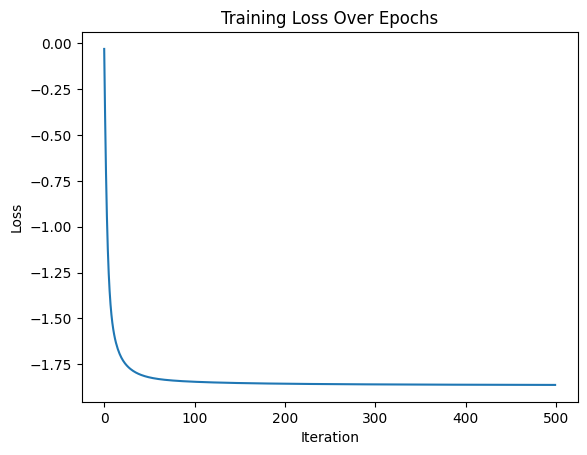

In [8]:
import sim_tangram.train_tangram as tg_cca
import torch

# tangram
tangram_sim, _ = tg_cca.read_csv_and_run_tangram(
    [torch.tensor(latent_gene, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_img, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([3366, 128, 1])
G: torch.Size([3366, 128, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:00<00:00, 592.88it/s]

Epoch 500: Loss -1.8221732378005981
[[ 4.7670145e+00  6.0073962e+00  5.7353597e+00 ...  1.1586099e+00
  -2.8961122e+00  5.0313902e-01]
 [ 5.0869741e+00  5.3576779e+00  2.9034126e+00 ... -2.1490574e-01
  -2.8668764e+00  1.4612108e+00]
 [ 4.3668742e+00  4.9628716e+00  3.2353559e+00 ... -9.0687968e-02
  -2.6357720e+00  2.7471609e+00]
 ...
 [-2.4997118e+00 -2.2838564e+00 -1.4756403e+00 ...  9.6165733e+00
  -3.0868568e+00 -1.4045795e+00]
 [-6.9645441e-01 -1.1351816e-02 -9.8162621e-01 ... -2.5970128e+00
   8.8985252e+00  1.0820518e+01]
 [-1.5269563e+00  8.7728584e-01 -7.0110565e-01 ... -1.4624883e+00
   1.1376467e+01  1.0413607e+01]]


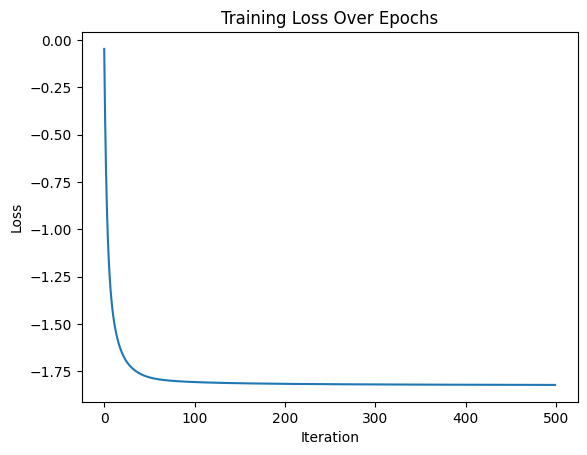

In [9]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_gene, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_img, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [10]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_gene, latent_img)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_sim_tg.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
tangram_mapping = tangram_sim.argmax(axis=1)
for i in range(len(tangram_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {tangram_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:   15	 1:   15	 2:   15	 3:   15	 4:   15	
 5:   15	 6:   15	 7:   15	 8:   15	 9:   15	
10:   15	11:   15	12:   15	13:   15	14:   15	
15:   15	16:   15	17:   15	18:   28	19:   28	
20:   28	21:   28	22:   28	23:   28	24:   28	
25:   28	26:   28	27:   28	28:   28	29:   55	
**************************************************

 0:   12	 1:    4	 2: 2071	 3:  643	 4:  111	
 5:    0	 6: 2593	 7:   14	 8:    1	 9:   16	
10: 1830	11: 1933	12:    2	13: 2814	14: 1569	
15:    6	16: 1917	17:    3	18:   27	19:   19	
20: 1999	21: 3030	22:   26	23:  418	24:   23	
25: 2893	26: 1945	27:  551	28:   21	29: 2059	
**************************************************

 0:   12	 1:    4	 2:  173	 3:  643	 4: 1600	
 5:    0	 6: 1769	 7:   14	 8:    1	 9:   16	
10: 1830	11: 1933	12:    2	13: 2814	14:    7	
15:    6	16: 1346	17:    3	18:   27	19:   19	
20: 3078	21:   25	22:   26	23:  264	24:   23	
25: 2893	26: 2290	27: 2679	28:   28	29: 2059	
**************************************************


In [11]:
# 计算acc
sample_size = latent_gene.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(tangram_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 0.060308972073677955
tangram accuracy: 0.035650623885918005
cos_tg accuracy: 0.03535353535353535
